In [1]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("coins", {}, "./coins/coco-1612779490.2197058.json", "./coins")

/Users/okumuradaichi/opt/anaconda3/lib/python3.9/site-packages/google/colab/data_table.py:30: UserWarning: IPython.utils.traitlets has moved to a top-level traitlets package.
  from IPython.utils import traitlets as _traitlets

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



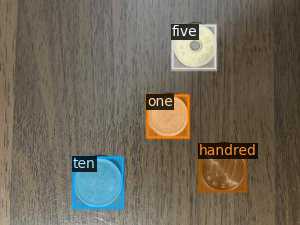

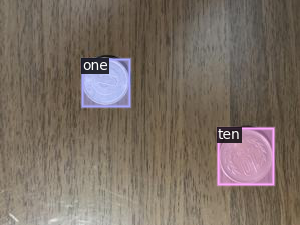

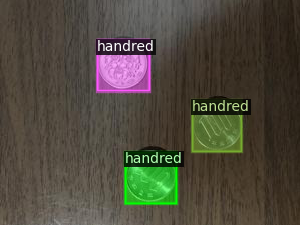

In [2]:
from detectron2.data import MetadataCatalog
from detectron2.data import DatasetCatalog
import random
import cv2
from detectron2.utils.visualizer import Visualizer
from google.colab.patches import cv2_imshow

coins_metadata = MetadataCatalog.get("coins")
dataset_dicts = DatasetCatalog.get("coins")

for d in random.sample(dataset_dicts, 3):
  img = cv2.imread(d["file_name"])
  visualizer = Visualizer(img[:, :, ::-1], metadata=coins_metadata, scale=1.0)
  vis = visualizer.draw_dataset_dict(d)
  cv2_imshow(vis.get_image()[:, :, ::-1])

In [3]:
from detectron2.engine import DefaultTrainer
import os
import cv2
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.logger import setup_logger
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import Visualizer
import datetime

cfg = get_cfg()
cfg.MODEL.DEVICE = 'cpu'
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("coins",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0004
cfg.SOLVER.MAX_ITER = (
    500
)
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = (
    128
)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[06/21 23:19:27 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (5, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (5,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (16, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (16,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, 

[06/21 23:19:27 d2.engine.train_loop]: Starting training from iteration 0


/Users/okumuradaichi/opt/anaconda3/lib/python3.9/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /Users/distiller/project/conda/conda-bld/pytorch_1646756029501/work/aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[06/21 23:27:39 d2.utils.events]:  eta: 3:14:57  iter: 19  total_loss: 2.387  loss_cls: 1.452  loss_box_reg: 0.8885  loss_rpn_cls: 0.001461  loss_rpn_loc: 0.004297  time: 23.9599  data_time: 0.1474  lr: 1.5585e-05  
[06/21 23:35:30 d2.utils.events]:  eta: 3:04:34  iter: 39  total_loss: 2.023  loss_cls: 1.128  loss_box_reg: 0.9303  loss_rpn_cls: 0.001074  loss_rpn_loc: 0.004394  time: 23.7429  data_time: 0.0016  lr: 3.1569e-05  
[06/21 23:43:22 d2.utils.events]:  eta: 2:52:21  iter: 59  total_loss: 1.57  loss_cls: 0.7096  loss_box_reg: 0.8624  loss_rpn_cls: 0.001903  loss_rpn_loc: 0.003521  time: 23.6882  data_time: 0.0016  lr: 4.7553e-05  
[06/21 23:51:42 d2.utils.events]:  eta: 2:50:51  iter: 79  total_loss: 1.487  loss_cls: 0.5809  loss_box_reg: 0.8696  loss_rpn_cls: 0.001328  loss_rpn_loc: 0.003447  time: 24.0196  data_time: 0.0020  lr: 6.3537e-05  
[06/22 00:00:20 d2.utils.events]:  eta: 2:43:33  iter: 99  total_loss: 1.419  loss_cls: 0.5239  loss_box_reg: 0.9082  loss_rpn_cls: 0.0

In [1]:
import os
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo
import cv2
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from google.colab.patches import cv2_imshow
from detectron2.data import DatasetCatalog


from detectron2.data.datasets import register_coco_instances
register_coco_instances("coins", {}, "./coins/coco-1612779490.2197058.json", "./coins")
coins_metadata = MetadataCatalog.get("coins")
dataset_dicts = DatasetCatalog.get("coins")
cfg = get_cfg()

cfg.MODEL.DEVICE = 'cpu'
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = (128)
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("coins",)
cfg.DATASETS.TEST = ()
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.6
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4
predictor = DefaultPredictor(cfg)

/Users/okumuradaichi/opt/anaconda3/lib/python3.9/site-packages/google/colab/data_table.py:30: UserWarning: IPython.utils.traitlets has moved to a top-level traitlets package.
  from IPython.utils import traitlets as _traitlets

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



/Users/okumuradaichi/opt/anaconda3/lib/python3.9/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /Users/distiller/project/conda/conda-bld/pytorch_1646756029501/work/aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


203円


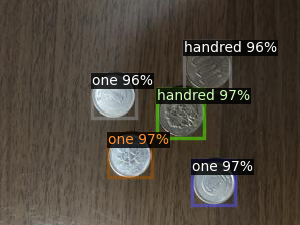

In [2]:
im = cv2.imread("./coins_test/IMG_4695.jpg")
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1],
               metadata=coins_metadata, 
               scale=1.0
              )
data = outputs["instances"].to("cpu")
scores_np = data.get("scores").to('cpu').detach().numpy().copy()
classes_np = data.get("pred_classes").to('cpu').detach().numpy().copy()
cash_data = [1, 5, 10, 100]
cash_sum = 0
for i, n in enumerate(classes_np):
    if scores_np[i] > 0.9:
        cash_sum += cash_data[n]
print(str(cash_sum) + "円")
v = v.draw_instance_predictions(data)
cv2_imshow(v.get_image()[:, :, ::-1])